In [7]:
import pandas as pd
import numpy as np
data=pd.read_csv("output.csv",header=None,
names=["id","appid","content","authorid","review"])

C:\Users\admin\AppData\Local\Temp\ipykernel_13288\4082144922.py:3: DtypeWarning: Columns (0,1,3) have mixed types. Specify dtype option on import or set low_memory=False.
  data=pd.read_csv("output.csv",header=None,


In [2]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 201152 entries, 0 to 201151
Data columns (total 5 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   id        201152 non-null  object
 1   appid     201152 non-null  object
 2   content   200724 non-null  object
 3   authorid  201152 non-null  object
 4   review    201152 non-null  object
dtypes: object(5)
memory usage: 7.7+ MB


In [9]:
df=data

In [10]:
df.isnull().sum().sum()

np.int64(428)

In [12]:
data

,id,appid,content,authorid,review
0,id,app_id,content,author_id,is_positive
1,181331361,100,At least its a counter strike -1/100,76561199556485100,Negative
2,180872601,100,Uh... So far my playthrough has not been great...,76561199230620391,Negative
3,177836246,100,Better mechanics than cs2,76561198417690647,Negative
4,177287444,100,buggy mess and NOT fun to play at all,76561199077268730,Negative
...,...,...,...,...,...
201147,118775009,570,This trash for sick anime clowns!,76561198393884121,Negative
201148,118771828,570,Not noob friendly,76561198077888096,Negative
201149,118771331,570,Total trash for anime clowns!,76561198819460083,Negative
201150,182234883,730,Unplayable. It keeps trying to update but then...,76561198084125683,Negative


In [15]:
df = data.drop(index=0).reset_index(drop=True)
df


,id,appid,content,authorid,review
0,177836246,100,Better mechanics than cs2,76561198417690647,Negative
1,177287444,100,buggy mess and NOT fun to play at all,76561199077268730,Negative
2,176678990,100,"Whoever came up with this, is gonna fucking ge...",76561199104544266,Negative
3,176118004,100,Every enemy and their grandmother have aimbot ...,76561198296823531,Negative
4,172896379,100,l,76561199182060159,Negative
...,...,...,...,...,...
201144,118775009,570,This trash for sick anime clowns!,76561198393884121,Negative
201145,118771828,570,Not noob friendly,76561198077888096,Negative
201146,118771331,570,Total trash for anime clowns!,76561198819460083,Negative
201147,182234883,730,Unplayable. It keeps trying to update but then...,76561198084125683,Negative


In [16]:
df.fillna(0, inplace=True)

In [17]:
df["review"].value_counts()

review
Positive    102660
Negative     98489
Name: count, dtype: int64

In [18]:
valid = ["Negative", "Positive"]
df= df[df["review"].isin(valid)]

In [19]:
sent_map = {"Negative":0, "Positive":1}
df["label"] = df["review"].map(sent_map)

In [20]:
from sklearn.model_selection import train_test_split

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    df["content"], df["label"], test_size=0.2, random_state=42
)

In [23]:
X_train = X_train.astype(str)
X_test = X_test.astype(str)

In [24]:
X_train = X_train.fillna("").astype(str)
X_test = X_test.fillna("").astype(str)

In [25]:
tokenizer = Tokenizer(num_words=20000, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

max_len = 40
X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding="post")
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding="post")

In [26]:
df

,id,appid,content,authorid,review,label
0,177836246,100,Better mechanics than cs2,76561198417690647,Negative,0
1,177287444,100,buggy mess and NOT fun to play at all,76561199077268730,Negative,0
2,176678990,100,"Whoever came up with this, is gonna fucking ge...",76561199104544266,Negative,0
3,176118004,100,Every enemy and their grandmother have aimbot ...,76561198296823531,Negative,0
4,172896379,100,l,76561199182060159,Negative,0
...,...,...,...,...,...,...
201144,118775009,570,This trash for sick anime clowns!,76561198393884121,Negative,0
201145,118771828,570,Not noob friendly,76561198077888096,Negative,0
201146,118771331,570,Total trash for anime clowns!,76561198819460083,Negative,0
201147,182234883,730,Unplayable. It keeps trying to update but then...,76561198084125683,Negative,0


In [27]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

model = Sequential([
    Embedding(input_dim=20000, output_dim=64, input_length=max_len),
    SimpleRNN(64, return_sequences=False),
    Dense(32, activation="relu"),
    Dense(1, activation="sigmoid")   #2-class output
])

c:\Users\admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [28]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [29]:
# Explicitly build the model before printing the summary
model.build(input_shape=(None, max_len))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 40, 64)         │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,290,369 (4.92 MB)

 Trainable params: 1,290,369 (4.92 MB)

 Non-trainable params: 0 (0.00 B)

In [30]:
history=model.fit(
    X_train_pad, y_train,
    validation_split=0.2,
    epochs=5,
    batch_size=64
)

loss, acc = model.evaluate(X_test_pad, y_test)
print("Test Accuracy:", acc)

Epoch 1/5


c:\Users\admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\losses\losses.py:33: SyntaxWarning: In loss categorical_crossentropy, expected y_pred.shape to be (batch_size, num_classes) with num_classes > 1. Received: y_pred.shape=(None, 1). Consider using 'binary_crossentropy' if you only have 2 classes.
  return self.fn(y_true, y_pred, **self._fn_kwargs)


2012/2012 ━━━━━━━━━━━━━━━━━━━━ 51s 24ms/step - accuracy: 0.4909 - loss: 0.0000e+00 - val_accuracy: 0.4874 - val_loss: 0.0000e+00
Epoch 2/5
2012/2012 ━━━━━━━━━━━━━━━━━━━━ 46s 23ms/step - accuracy: 0.4910 - loss: 0.0000e+00 - val_accuracy: 0.4874 - val_loss: 0.0000e+00
Epoch 3/5
2012/2012 ━━━━━━━━━━━━━━━━━━━━ 45s 23ms/step - accuracy: 0.4910 - loss: 0.0000e+00 - val_accuracy: 0.4874 - val_loss: 0.0000e+00
Epoch 4/5
2012/2012 ━━━━━━━━━━━━━━━━━━━━ 47s 23ms/step - accuracy: 0.4910 - loss: 0.0000e+00 - val_accuracy: 0.4874 - val_loss: 0.0000e+00
Epoch 5/5
2012/2012 ━━━━━━━━━━━━━━━━━━━━ 46s 23ms/step - accuracy: 0.4910 - loss: 0.0000e+00 - val_accuracy: 0.4874 - val_loss: 0.0000e+00
1258/1258 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.4871 - loss: 0.0000e+00
Test Accuracy: 0.4870743155479431


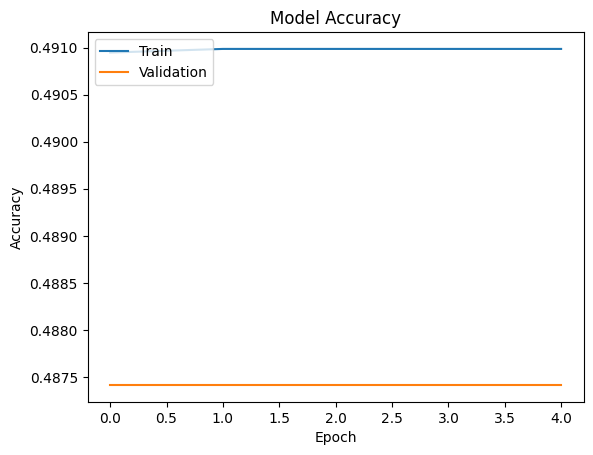

In [31]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

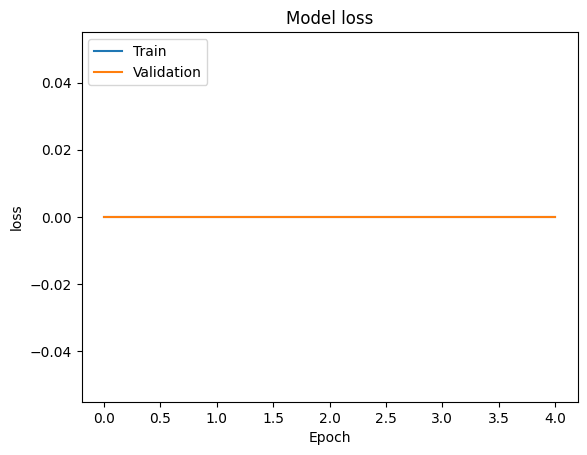

In [32]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

In [33]:
from sklearn.metrics import confusion_matrix, classification_report
y_pred = model.predict(X_test_pad)
y_pred_labels = np.argmax(y_pred, axis=1)
cm = confusion_matrix(y_test, y_pred_labels)
print(classification_report(y_test, y_pred_labels))

1258/1258 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step
              precision    recall  f1-score   support

           0       0.49      1.00      0.66     19595
           1       0.00      0.00      0.00     20635

    accuracy                           0.49     40230
   macro avg       0.24      0.50      0.33     40230
weighted avg       0.24      0.49      0.32     40230



c:\Users\admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

In [34]:
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense,LSTM

In [35]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

model = Sequential([
    Embedding(input_dim=20000, output_dim=64, input_length=max_len),
    LSTM(64, return_sequences=False),
    Dense(32, activation="relu"),
    Dense(1, activation="sigmoid")   # 2-class output
])

model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)


c:\Users\admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [36]:
# Explicitly build the model before printing the summary
model.build(input_shape=(None, max_len))
model.summary()

history = model.fit(
    X_train_pad, y_train,
    validation_split=0.2,
    epochs=5,
    batch_size=64
)

loss, acc = model.evaluate(X_test_pad, y_test)
print("Test Accuracy:", acc)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 40, 64)         │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,315,137 (5.02 MB)

 Trainable params: 1,315,137 (5.02 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
2012/2012 ━━━━━━━━━━━━━━━━━━━━ 76s 36ms/step - accuracy: 0.6828 - loss: 0.5945 - val_accuracy: 0.8139 - val_loss: 0.4100
Epoch 2/5
2012/2012 ━━━━━━━━━━━━━━━━━━━━ 71s 35ms/step - accuracy: 0.8371 - loss: 0.3683 - val_accuracy: 0.8403 - val_loss: 0.3588
Epoch 3/5
2012/2012 ━━━━━━━━━━━━━━━━━━━━ 70s 35ms/step - accuracy: 0.8654 - loss: 0.3126 - val_accuracy: 0.8386 - val_loss: 0.3540
Epoch 4/5
2012/2012 ━━━━━━━━━━━━━━━━━━━━ 89s 38ms/step - accuracy: 0.8774 - loss: 0.2882 - val_accuracy: 0.8470 - val_loss: 0.3572
Epoch 5/5
2012/2012 ━━━━━━━━━━━━━━━━━━━━ 83s 41ms/step - accuracy: 0.8876 - loss: 0.2666 - val_accuracy: 0.8446 - val_loss: 0.3705
1258/1258 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - accuracy: 0.8422 - loss: 0.3705
Test Accuracy: 0.8422321677207947


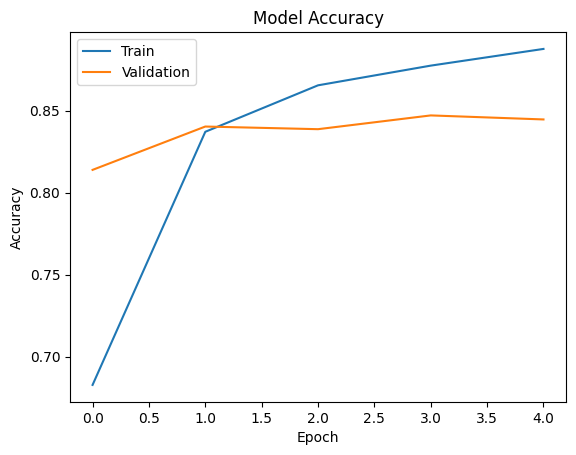

In [37]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

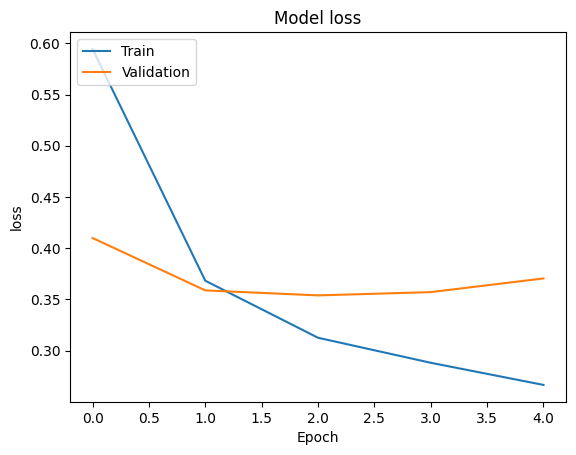

In [38]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

In [39]:
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense,LSTM,Bidirectional

In [40]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Bidirectional

model = Sequential([
    Embedding(input_dim=20000, output_dim=64, input_length=max_len),
    Bidirectional(LSTM(64, return_sequences=False)),
    Dense(32, activation="relu"),
    Dense(1, activation="sigmoid")   # two-class output
])

model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)


In [41]:
# Explicitly build the model before printing the summary
model.build(input_shape=(None, max_len))
model.summary()

history = model.fit(
    X_train_pad, y_train,
    validation_split=0.2,
    epochs=5,
    batch_size=64
)

loss, acc = model.evaluate(X_test_pad, y_test)
print("Test Accuracy:", acc)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 40, 64)         │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,350,209 (5.15 MB)

 Trainable params: 1,350,209 (5.15 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
2012/2012 ━━━━━━━━━━━━━━━━━━━━ 72s 33ms/step - accuracy: 0.8254 - loss: 0.3760 - val_accuracy: 0.8475 - val_loss: 0.3375
Epoch 2/5
2012/2012 ━━━━━━━━━━━━━━━━━━━━ 62s 31ms/step - accuracy: 0.8690 - loss: 0.2981 - val_accuracy: 0.8546 - val_loss: 0.3282
Epoch 3/5
2012/2012 ━━━━━━━━━━━━━━━━━━━━ 94s 47ms/step - accuracy: 0.8876 - loss: 0.2611 - val_accuracy: 0.8535 - val_loss: 0.3337
Epoch 4/5
2012/2012 ━━━━━━━━━━━━━━━━━━━━ 102s 51ms/step - accuracy: 0.9014 - loss: 0.2300 - val_accuracy: 0.8536 - val_loss: 0.3571
Epoch 5/5
2012/2012 ━━━━━━━━━━━━━━━━━━━━ 103s 51ms/step - accuracy: 0.9138 - loss: 0.2041 - val_accuracy: 0.8496 - val_loss: 0.3845
1258/1258 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - accuracy: 0.8478 - loss: 0.3882
Test Accuracy: 0.8478249907493591


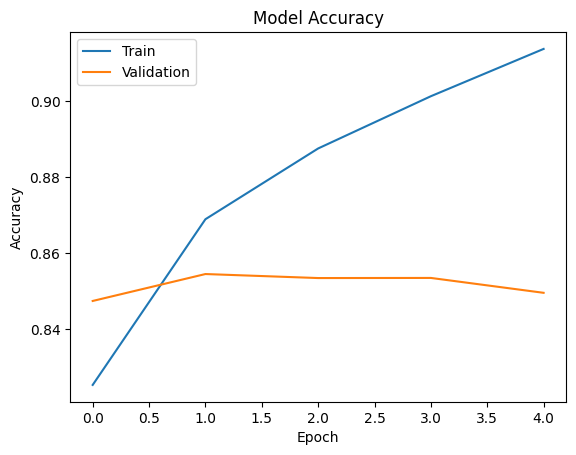

In [42]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

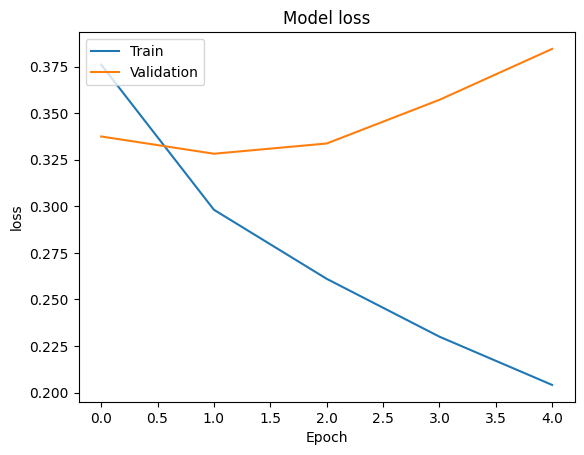

In [43]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

In [44]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dense

model = Sequential([
    Embedding(input_dim=20000, output_dim=64, input_length=max_len),
    GRU(64, return_sequences=False),
    Dense(32, activation="relu"),
    Dense(1, activation="sigmoid")   # 🔥 2-class output
])

model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)


In [45]:
# Explicitly build the model before printing the summary
model.build(input_shape=(None, max_len))
model.summary()

history = model.fit(
    X_train_pad, y_train,
    validation_split=0.2,
    epochs=5,
    batch_size=64
)

loss, acc = model.evaluate(X_test_pad, y_test)
print("Test Accuracy:", acc)

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 40, 64)         │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 64)             │        24,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,307,073 (4.99 MB)

 Trainable params: 1,307,073 (4.99 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
2012/2012 ━━━━━━━━━━━━━━━━━━━━ 53s 25ms/step - accuracy: 0.7672 - loss: 0.4557 - val_accuracy: 0.8452 - val_loss: 0.3454
Epoch 2/5
2012/2012 ━━━━━━━━━━━━━━━━━━━━ 50s 25ms/step - accuracy: 0.8644 - loss: 0.3115 - val_accuracy: 0.8515 - val_loss: 0.3358
Epoch 3/5
2012/2012 ━━━━━━━━━━━━━━━━━━━━ 51s 25ms/step - accuracy: 0.8800 - loss: 0.2796 - val_accuracy: 0.8514 - val_loss: 0.3405
Epoch 4/5
2012/2012 ━━━━━━━━━━━━━━━━━━━━ 51s 25ms/step - accuracy: 0.8948 - loss: 0.2499 - val_accuracy: 0.8523 - val_loss: 0.3529
Epoch 5/5
2012/2012 ━━━━━━━━━━━━━━━━━━━━ 50s 25ms/step - accuracy: 0.9062 - loss: 0.2211 - val_accuracy: 0.8495 - val_loss: 0.3751
1258/1258 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8468 - loss: 0.3805
Test Accuracy: 0.8468307256698608


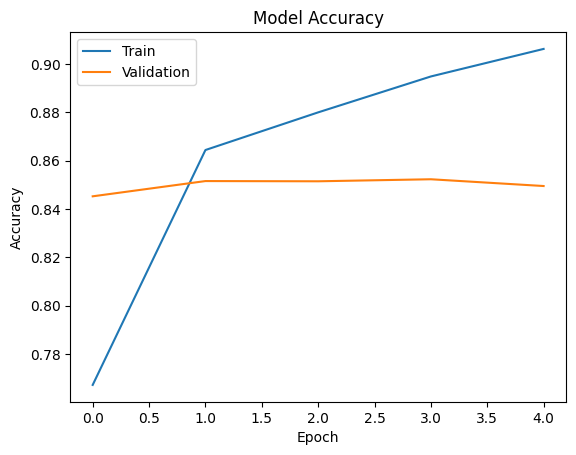

In [46]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

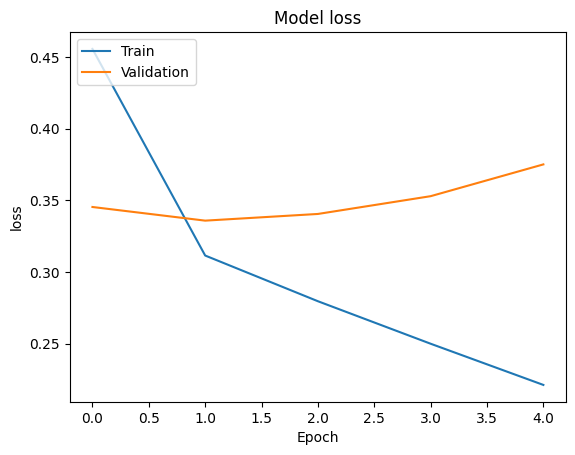

In [47]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')